## VGAE avec GAT pour comparer avec VGAE sans GAT

La Loss du train semble bizzare et le résultat global n'est pas concluent. Il faudrait qu'on repasse sur les préprocessing imo

In [30]:
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch as th
import torch.nn.functional as F
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import GCNConv, GATv2Conv, VGAE   # ajouter GATv2Conv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx
from torch import device


In [27]:
from torch import load

train_data = load('../data/train_data.pt',weights_only=False)
val_data = load('../data/val_data.pt',weights_only=False)
test_data = load('../data/test_data.pt',weights_only=False)

data = load('../data/data.pt',weights_only=False)

In [ ]:
# (b) Build your Encoder which compute mu and logstd of a distribution
# and the train function associated
# class Encoder(nn.Module):
#     def __init__(...
from torch import nn
from torch_geometric.nn import GCNConv, VGAE

# Encoder modifié en GAT_Encoder
# AJout de 
class GAT_Encoder(nn.Module):
    def __init__(self, dim_in, hidden_channels, dim_out, heads=4, p=0.3):
        super(GAT_Encoder, self).__init__()
        self.p = p
        self.conv1 = GATv2Conv(dim_in, hidden_channels, heads=heads, dropout=p)
        self.conv_mu = GATv2Conv(hidden_channels * heads, dim_out, heads=1, concat=False)
        self.conv_logstd = GATv2Conv(hidden_channels * heads, dim_out, heads=1, concat=False)

    def forward(self, x, edge_index):
        h = F.elu(self.conv1(x, edge_index))
        h = F.dropout(h, p=self.p, training=self.training)
        return self.conv_mu(h, edge_index), self.conv_logstd(h, edge_index)

model = VGAE(GAT_Encoder(dim_in=4, hidden_channels=16, dim_out=16))
optimizer = th.optim.Adam(model.parameters(), lr=0.005) 

            
def train(model, train_data,val_data, optimizer, epochs):
    history = {"train": [], "val": []}
    for epoch in range(epochs):
        model.train()
        # initialize the gradients
        optimizer.zero_grad()
        # forward pass
        z= model.encode(train_data.x, train_data.edge_index)
        #mu, logstd = model(data.x, data.edge_index)
        # compute the loss
        loss = model.recon_loss(
                z,
                train_data.pos_edge_label_index,
                train_data.neg_edge_label_index,
            ) + model.kl_loss() / train_data.num_nodes
        
        #loss=model.recon_loss(z, train_data.pos_edge_label_index,)
        #      +(1/train_data.num_nodes)*model.kl_loss()
        
        #loss = compute_loss(mu, logstd, data)
        print(f"Epoch {epoch}, Loss: {loss.item()}")
        # backpropagation and optimization step
        loss.backward()
        optimizer.step()
        history["train"].append(loss.item())
        # validation loss
        model.eval()
        #  attention, pour ne pas calculer les gradients sur les données de validation
        with th.no_grad():
            z_val = model.encode(val_data.x, val_data.edge_index)
            val_loss = model.recon_loss(
                z_val,
                val_data.pos_edge_label_index,
                val_data.neg_edge_label_index,
            ) + model.kl_loss() / val_data.num_nodes
            print(f"Epoch {epoch}, Validation Loss: {val_loss.item()}")
            history["val"].append(val_loss.item())
    return history

In [43]:
# (c) Initialize your model using VGAE from torch geometric.nn, then train it
# here instanciate the model, then train and test it
model_a = VGAE(GAT_Encoder(data.num_features,32,16))

optimizer_a = th.optim.Adam(model_a.parameters(), lr=0.01)
loss_a = train(model_a, train_data, val_data, optimizer=optimizer_a, epochs=200)

model_b = VGAE(GAT_Encoder(data.num_features,128,16))
GAT_Encoderoptimizer_b = th.optim.Adam(model_b.parameters(), lr=0.01)
loss_b = train(model_b, train_data, val_data, optimizer=optimizer_b, epochs=500)


model_c = VGAE(GAT_Encoder(data.num_features,6,6))
optimizer_c = th.optim.Adam(model_c.parameters(), lr=0.01)
loss_c = train(model_c, train_data, val_data, optimizer=optimizer_c, epochs=500)



Epoch 0, Loss: 4183545344.0
Epoch 0, Validation Loss: 3315110656.0
Epoch 1, Loss: 6067596800.0
Epoch 1, Validation Loss: 1718713984.0
Epoch 2, Loss: 3443391744.0
Epoch 2, Validation Loss: 210038288.0
Epoch 3, Loss: 2197033984.0
Epoch 3, Validation Loss: 43253340.0
Epoch 4, Loss: 1292785152.0
Epoch 4, Validation Loss: 56699500.0
Epoch 5, Loss: 599670976.0
Epoch 5, Validation Loss: 90242760.0
Epoch 6, Loss: 469786816.0
Epoch 6, Validation Loss: 126748048.0
Epoch 7, Loss: 313751456.0
Epoch 7, Validation Loss: 159844368.0
Epoch 8, Loss: 203080128.0
Epoch 8, Validation Loss: 186569904.0
Epoch 9, Loss: 277718592.0
Epoch 9, Validation Loss: 205550624.0
Epoch 10, Loss: 214850272.0
Epoch 10, Validation Loss: 217903184.0
Epoch 11, Loss: 231821216.0
Epoch 11, Validation Loss: 222450912.0
Epoch 12, Loss: 226482288.0
Epoch 12, Validation Loss: 220588192.0
Epoch 13, Loss: 181800896.0
Epoch 13, Validation Loss: 214512000.0
Epoch 14, Loss: 174478512.0
Epoch 14, Validation Loss: 205372320.0
Epoch 15, L

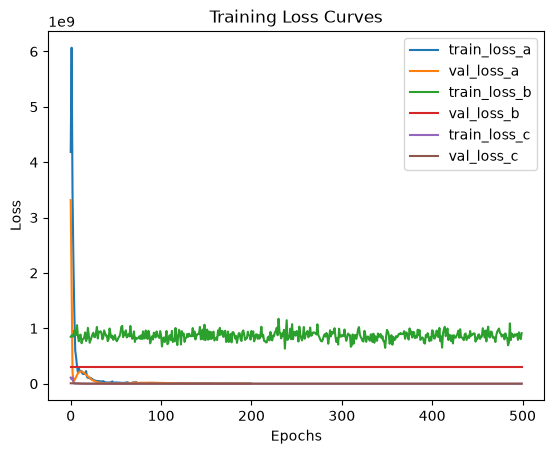

In [44]:
# afficher les courbes loss_a
import matplotlib.pyplot as plt
plt.plot(loss_a["train"], label="train_loss_a")
plt.plot(loss_a["val"], label="val_loss_a")
plt.plot(loss_b["train"], label="train_loss_b")
plt.plot(loss_b["val"], label="val_loss_b")
plt.plot(loss_c["train"], label="train_loss_c")
plt.plot(loss_c["val"], label="val_loss_c")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.show()

In [45]:
def afficher_matrice_confusion(lemodele,donnees_testees, titre):
    
    # eval() met le modèle en mode évaluation, désactivant certaines fonctionnalités comme le dropout et la normalisation par lot qui ne sont utilisées que pendant l'entraînement.
    lemodele.eval()
    
    with th.no_grad():
        
        # Encodage des nœuds pour obtenir leurs représentations latentes.
        z = lemodele.encode(donnees_testees.x, donnees_testees.edge_index)
        
        # Récupération de toutes les arêtes positives et négatives 
        pos_edges = donnees_testees.pos_edge_label_index
        neg_edges = donnees_testees.neg_edge_label_index
        edges = th.cat([pos_edges, neg_edges], dim=1)

        probabilites = lemodele.decode(z, edges, sigmoid=True)
        perf=lemodele.test(z, pos_edges, neg_edges)  
        predictions = (probabilites >= 0.5).long().cpu().numpy()

        vrais_labels = th.cat([
            th.ones(pos_edges.size(1), dtype=th.long),
            th.zeros(neg_edges.size(1), dtype=th.long),
        ]).numpy()

    matrice = confusion_matrix(vrais_labels, predictions, labels=[0, 1])
    print(f"\nMatrice de confusion — {titre}")
    print("Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]")
    print(matrice)
    auc, ap = perf
    print(f"Perf : AUC {auc:.3f} (vrais positifs / faux positifs) - AP {ap:.3f} (précision / rappel)")
    # print(f"Perf : AUC {perf[1]} (vrai_positif/faux_positif) - AP {perf[2]} ( précision/rappel )")



afficher_matrice_confusion(model_a, train_data, "model_a train_data ")
afficher_matrice_confusion(model_a, test_data, "model_a test_data")

afficher_matrice_confusion(model_b, train_data, "model_b train_data ")
afficher_matrice_confusion(model_b, test_data, "model_b test_data")

afficher_matrice_confusion(model_c, train_data, "model_c train_data ")
afficher_matrice_confusion(model_c, test_data, "model_c test_data")
    


Matrice de confusion — model_a train_data 
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[   0 9484]
 [   0 9484]]
Perf : AUC 0.500 (vrais positifs / faux positifs) - AP 0.500 (précision / rappel)

Matrice de confusion — model_a test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[   0 2709]
 [   0 2709]]
Perf : AUC 0.500 (vrais positifs / faux positifs) - AP 0.500 (précision / rappel)

Matrice de confusion — model_b train_data 
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[   0 9484]
 [   0 9484]]
Perf : AUC 0.500 (vrais positifs / faux positifs) - AP 0.500 (précision / rappel)

Matrice de confusion — model_b test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[   0 2709]
 [   0 2709]]
Perf : AUC 0.500 (vrais positifs / faux positifs) - AP 0.500 (précision / rappel)

Matrice de confusion — model_c train_data 
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-ar

In [46]:
z  =model_a.encode(test_data.x, test_data.edge_index)
#
probabilites = model_a.decode(z, test_data.pos_edge_label_index, sigmoid=True)

pos_edges = test_data.pos_edge_label_index
neg_edges = test_data.neg_edge_label_index
perf=model_a.test(z, pos_edges, neg_edges)  
print(perf)

(0.5, 0.5)


In [47]:
test_data.pos_edge_label_index

tensor([[1247,  144,  143,  ...,  273, 1554,  286],
        [1853, 1074, 1312,  ..., 1855, 2275, 1889]])